In [5]:
#Loading and Plotting Data
#For the first part, we'll be doing linear regression with one variable, 
#and so we'll use only two fields from the daily data set: 
#the normalized high temperature in C, and the total number of bike rentals.


import pandas as pd

data = pd.read_csv("linear_data.csv")
temps = data['atemp'].values
rentals = data['cnt'].values / 1000

In [6]:
#The plot reveals some degree of correlation between temperature and bike rentals, as one might guess.

Text(0, 0.5, 'Bike Rentals in 1000s')

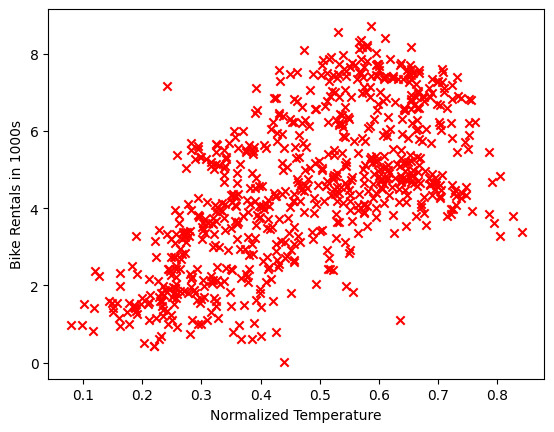

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(temps, rentals, marker='x', color='red')
plt.xlabel('Normalized Temperature')
plt.ylabel('Bike Rentals in 1000s')

In [8]:
import numpy as np

def compute_cost(X, y, theta):
    return np.sum(np.square(np.matmul(X, theta) - y)) / (2 * len(y))

In [9]:
#Before computing the cost with an initial guess for theta, a column of 1s is prepended onto the input data. 
#This allows us to vectorize the cost function, as well as make it usable for multiple linear regression later. 
#This first value theta zero now behaves as a constant in the cost function.

In [10]:
theta = np.zeros(2)
X = np.column_stack((np.ones(len(temps)), temps))
y = rentals
cost = compute_cost(X, y, theta)

print('theta:', theta)
print('cost:', cost)

theta: [0. 0.]
cost: 12.018406441176468


In [11]:
#We'll now minimize the cost using the gradient descent algorithm. Intuitively, gradient descent takes small, 
#linear hops down the slope of a function in each feature dimension, with the size of each hop determined
#by the partial derivative of the cost function with respect to that feature and a learning rate multiplier alpha
#If tuned properly, the algorithm converges on a global minimum by iteratively adjusting feature weights theta
#of the cost function

In [12]:
#See here for a more detailed explanation of how the update equations are derived.

In [13]:
def gradient_descent(X, y, alpha, iterations):
    theta = np.zeros(2)
    m = len(y)
    
    for i in range(iterations):
        t0 = theta[0] - (alpha / m) * np.sum(np.dot(X, theta) - y)
        t1 = theta[1] - (alpha / m) * np.sum((np.dot(X, theta) - y) * X[:,1])
        theta = np.array([t0, t1])

    return theta

iterations = 5000
alpha = 0.1

theta = gradient_descent(X, y, alpha, iterations)
cost = compute_cost(X, y, theta)

print("theta:", theta)
print('cost:', compute_cost(X, y, theta))

theta: [0.94588081 7.50171673]
cost: 1.1275869258439812


In [14]:
#We can examine the values of theta chosen by the algorithm using a few different visualizations, 
#first by plotting h0(x)against the input data. The results show the expected correlation between 
#temperature and rentals.

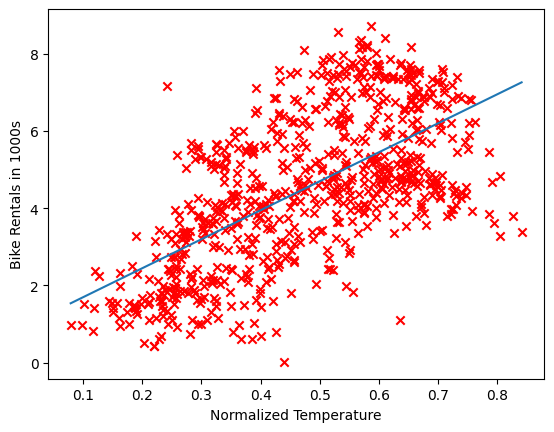

In [16]:
plt.scatter(temps, rentals, marker='x', color='red')
plt.xlabel('Normalized Temperature')
plt.ylabel('Bike Rentals in 1000s')
samples = np.linspace(min(temps), max(temps))
plt.plot(samples, theta[0] + theta[1] * samples)

In [13]:
#A surface plot is a better illustration of how gradient descent approaches a global minimum, 
#plotting the values for theta against their associated cost.

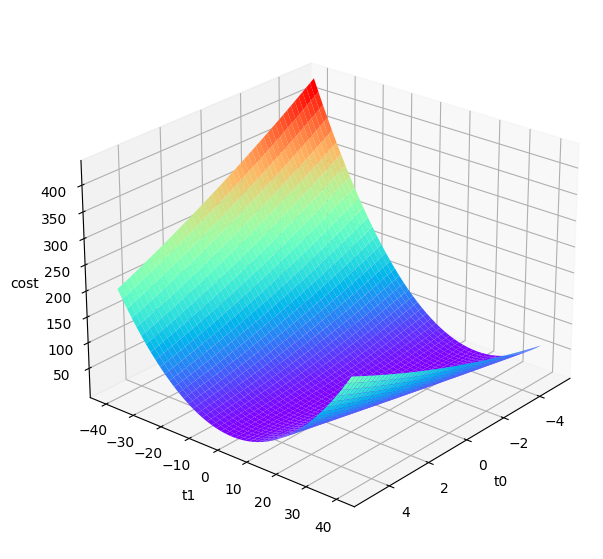

In [14]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

Xs, Ys = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-40, 40, 50))
Zs = np.array([compute_cost(X, y, [t0, t1]) for t0, t1 in zip(np.ravel(Xs), np.ravel(Ys))])
Zs = np.reshape(Zs, Xs.shape)

fig = plt.figure(figsize=(7,7))
ax = fig.gca(projection="3d")
ax.set_xlabel(r't0')
ax.set_ylabel(r't1')
ax.set_zlabel(r'cost')
ax.view_init(elev=25, azim=40)
ax.plot_surface(Xs, Ys, Zs, cmap=cm.rainbow)

In [15]:
#Finally, a countour plot reveals slices of that surface plot in 2D space, 
#and can show the resulting theta values sitting exactly at the global minimum.

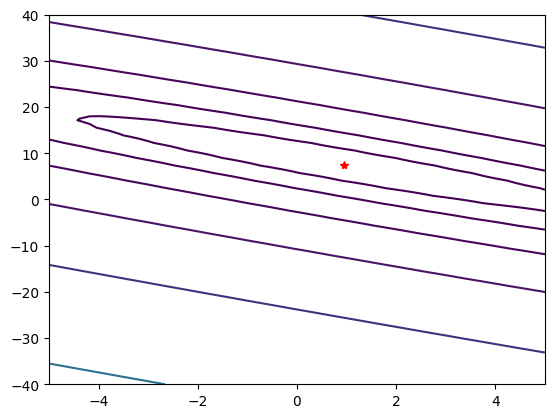

In [16]:
ax = plt.figure().gca()
ax.plot(theta[0], theta[1], 'r*')
plt.contour(Xs, Ys, Zs, np.logspace(-3, 3, 15))